In [4]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


RESULTS_DIR = Path("results")


def load_run(filepath):
    """Load a run JSON file and normalize both old and new formats."""
    with open(filepath) as f:
        raw = json.load(f)

    proto = raw["protocol"]
    M, N = proto["M"], proto["N"]
    use_qec = proto.get("use_qec", None)
    shots = raw["shots"]

    # Normalize tau_values: old format stores at top level, new inside protocol
    tau_values = proto.get("tau_values", raw.get("tau_values", []))

    # Normalize results into a list of dicts with consistent keys
    entries = []
    for key, entry in raw["results"].items():
        if "theta_idx" in entry:
            # New format
            entries.append({
                "theta_idx": entry["theta_idx"],
                "thetas": entry["thetas"],
                "tau": entry["tau"],
                "fidelities": entry["fidelities"],
                "counts": entry["counts"],
            })
        else:
            # Old format: key is the tau value string
            thetas = proto.get("thetas", [])
            entries.append({
                "theta_idx": 0,
                "thetas": thetas,
                "tau": int(key),
                "fidelities": entry["fidelities"],
                "counts": entry["counts"],
            })

    return {
        "filepath": str(filepath),
        "filename": Path(filepath).name,
        "timestamp": raw.get("timestamp", ""),
        "job_id": raw.get("job_id", ""),
        "backend": raw.get("backend", "unknown"),
        "shots": shots,
        "seed": raw.get("seed", None),
        "M": M,
        "N": N,
        "use_qec": use_qec,
        "nt": proto.get("nt", 1),
        "theta_samples": proto.get("theta_samples", [proto.get("thetas", [])]),
        "tau_values": sorted(set(tau_values)),
        "entries": entries,
    }


def list_runs():
    """List all available run files with summary info."""
    runs = []
    for f in sorted(RESULTS_DIR.glob("run_*.json")):
        try:
            r = load_run(f)
            runs.append(r)
        except Exception as e:
            print(f"Skipping {f.name}: {e}")
    return runs


def binomial_error(p, n):
    """Standard error for a binomial proportion."""
    return np.sqrt(p * (1 - p) / n) if n > 0 else 0.0


def latest_run():
    """Load the most recent run file."""
    files = sorted(RESULTS_DIR.glob("run_*.json"))
    if not files:
        raise FileNotFoundError("No run files found in results/")
    return load_run(files[-1])


print(f"Found {len(list(RESULTS_DIR.glob('run_*.json')))} run files in {RESULTS_DIR}/")
runs = list_runs()
for r in runs:
    qec_str = "QEC" if r["use_qec"] else "no-QEC"
    print(f"  {r['filename']}: M={r['M']}, N={r['N']}, {qec_str}, "
          f"nt={r['nt']}, taus={len(r['tau_values'])}, "
          f"backend={r['backend']}, shots={r['shots']}")

Found 8 run files in results/
  run_20260408_160814.json: M=1, N=2, no-QEC, nt=1, taus=41, backend=ibm_kingston, shots=4096
  run_20260408_161340.json: M=1, N=3, no-QEC, nt=1, taus=41, backend=ibm_marrakesh, shots=4096
  run_20260408_161902.json: M=1, N=4, no-QEC, nt=1, taus=41, backend=ibm_marrakesh, shots=4096
  run_20260408_162212.json: M=2, N=2, no-QEC, nt=1, taus=41, backend=ibm_marrakesh, shots=4096
  run_20260408_162440.json: M=2, N=3, no-QEC, nt=1, taus=41, backend=ibm_marrakesh, shots=4096
  run_20260408_162906.json: M=2, N=4, no-QEC, nt=1, taus=41, backend=ibm_fez, shots=4096
  run_20260408_163129.json: M=3, N=2, no-QEC, nt=1, taus=41, backend=ibm_marrakesh, shots=4096
  run_20260408_170544.json: M=1, N=2, no-QEC, nt=2, taus=41, backend=ibm_fez, shots=8192


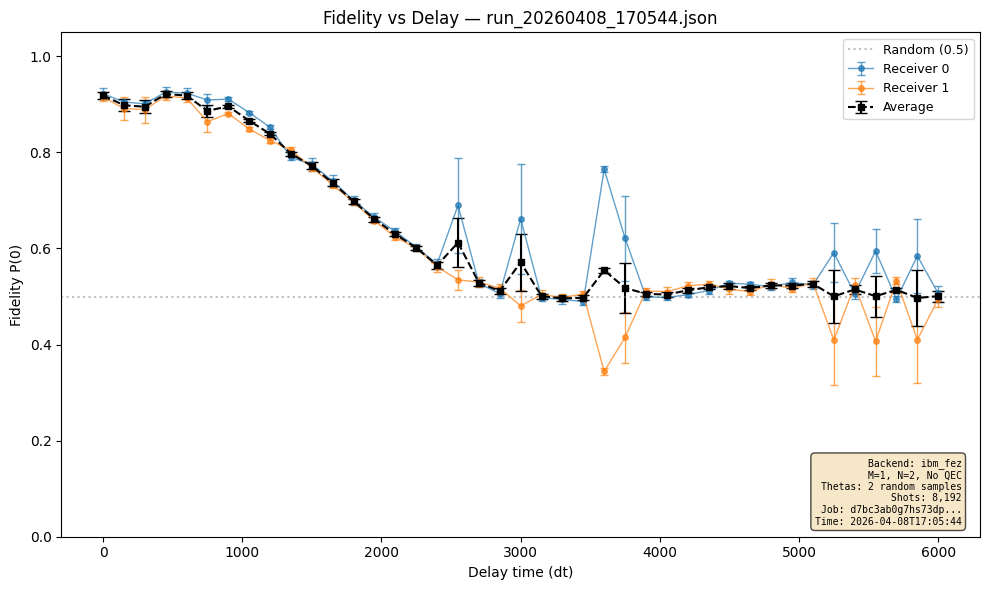

In [5]:
# --- Latest run: fidelity vs delay time with error bars ---

run = latest_run()
N = run["N"]
shots = run["shots"]
entries = run["entries"]

# Group entries by tau, averaging over theta samples
tau_data = {}
for e in entries:
    tau = e["tau"]
    if tau not in tau_data:
        tau_data[tau] = []
    tau_data[tau].append(e["fidelities"])

taus = sorted(tau_data.keys())
# Per-receiver: mean fidelity and error bar at each tau
recv_means = np.zeros((N, len(taus)))
recv_errs = np.zeros((N, len(taus)))

for j, tau in enumerate(taus):
    fid_matrix = np.array(tau_data[tau])  # shape (n_theta_samples, N)
    for i in range(N):
        fids = fid_matrix[:, i]
        mean_fid = np.mean(fids)
        # Combine shot noise and cross-theta variance
        shot_err = np.mean([binomial_error(f, shots) for f in fids])
        theta_err = np.std(fids) / np.sqrt(len(fids)) if len(fids) > 1 else 0.0
        recv_means[i, j] = mean_fid
        recv_errs[i, j] = np.sqrt(shot_err**2 + theta_err**2)

# Average across receivers
avg_means = np.mean(recv_means, axis=0)
avg_errs = np.sqrt(np.sum(recv_errs**2, axis=0)) / N

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

colors = plt.cm.tab10.colors
for i in range(N):
    ax.errorbar(taus, recv_means[i], yerr=recv_errs[i],
                fmt="o-", color=colors[i % len(colors)], capsize=3,
                markersize=4, linewidth=1, alpha=0.7,
                label=f"Receiver {i}")

ax.errorbar(taus, avg_means, yerr=avg_errs,
            fmt="s--", color="black", capsize=4,
            markersize=5, linewidth=1.5, label="Average")

ax.axhline(0.5, color="gray", linestyle=":", alpha=0.5, label="Random (0.5)")

ax.set_xlabel("Delay time (dt)")
ax.set_ylabel("Fidelity P(0)")
ax.set_ylim(0, 1.05)
ax.legend(loc="best", fontsize=9)

# Metadata annotation
qec_str = "QEC [[5,1,3]]" if run["use_qec"] else "No QEC"
theta_str = (f"{run['nt']} random samples" if run["nt"] > 1
            else f"[{', '.join(f'{t:.3f}' for t in run['theta_samples'][0])}]")
meta_lines = [
    f"Backend: {run['backend']}",
    f"M={run['M']}, N={run['N']}, {qec_str}",
    f"Thetas: {theta_str}",
    f"Shots: {run['shots']:,}",
    f"Job: {run['job_id'][:16]}..." if len(run["job_id"]) > 16 else f"Job: {run['job_id']}",
    f"Time: {run['timestamp'][:19]}",
]
meta_text = "\n".join(meta_lines)
ax.text(0.98, 0.02, meta_text, transform=ax.transAxes,
        fontsize=7, verticalalignment="bottom", horizontalalignment="right",
        fontfamily="monospace", bbox=dict(boxstyle="round,pad=0.4",
        facecolor="wheat", alpha=0.7))

ax.set_title(f"Fidelity vs Delay — {run['filename']}")
plt.tight_layout()
plt.show()

In [ ]:
# --- Multi-run comparison ---
# Select runs by filename (or index from the list printed in cell 1).
# Examples:
#   selected = runs                                    # all runs
#   selected = [runs[2], runs[5]]                      # by index
#   selected = [r for r in runs if r["M"] == 1]        # filter by M
#   selected = [r for r in runs if not r["use_qec"]]   # non-QEC only

selected = [r for r in runs if (len(r["tau_values"]) > 1) and (r["M"] == 1)]  # runs with a tau sweep

if not selected:
    print("No runs matched the selection criteria.")
else:
    n_runs = len(selected)
    ncols = min(n_runs, 3)
    nrows = int(np.ceil(n_runs / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows),
                            squeeze=False, sharey=True)

    for idx, run in enumerate(selected):
        ax = axes[idx // ncols][idx % ncols]
        N = run["N"]
        shots = run["shots"]

        # Group by tau, average over theta samples
        tau_data = {}
        for e in run["entries"]:
            tau = e["tau"]
            if tau not in tau_data:
                tau_data[tau] = []
            tau_data[tau].append(e["fidelities"])

        taus = sorted(tau_data.keys())
        recv_means = np.zeros((N, len(taus)))
        recv_errs = np.zeros((N, len(taus)))

        for j, tau in enumerate(taus):
            fid_matrix = np.array(tau_data[tau])
            for i in range(N):
                fids = fid_matrix[:, i]
                mean_fid = np.mean(fids)
                shot_err = np.mean([binomial_error(f, shots) for f in fids])
                theta_err = np.std(fids) / np.sqrt(len(fids)) if len(fids) > 1 else 0.0
                recv_means[i, j] = mean_fid
                recv_errs[i, j] = np.sqrt(shot_err**2 + theta_err**2)

        avg_means = np.mean(recv_means, axis=0)
        avg_errs = np.sqrt(np.sum(recv_errs**2, axis=0)) / N

        colors = plt.cm.tab10.colors
        for i in range(N):
            ax.errorbar(taus, recv_means[i], yerr=recv_errs[i],
                        fmt="o-", color=colors[i % len(colors)], capsize=2,
                        markersize=3, linewidth=0.8, alpha=0.6,
                        label=f"Recv {i}")

        ax.errorbar(taus, avg_means, yerr=avg_errs,
                    fmt="s--", color="black", capsize=3,
                    markersize=4, linewidth=1.2, label="Avg")

        ax.axhline(0.5, color="gray", linestyle=":", alpha=0.4)
        ax.set_ylim(0, 1.05)
        ax.set_xlabel("Delay (dt)", fontsize=9)
        if idx % ncols == 0:
            ax.set_ylabel("Fidelity P(0)", fontsize=9)
        ax.legend(fontsize=7, loc="upper right", ncol=2)

        # Title with key metadata
        qec_tag = "QEC" if run["use_qec"] else "no-QEC"
        ax.set_title(f"M={run['M']} N={run['N']} {qec_tag}\n"
                     f"{run['backend']} | {run['shots']} shots",
                     fontsize=9)

    # Blank out unused subplots
    for idx in range(n_runs, nrows * ncols):
        axes[idx // ncols][idx % ncols].set_visible(False)

    fig.suptitle("Multi-Run Comparison: Fidelity vs Delay Time", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

    print(f"Showing {n_runs} runs:")
    for i, r in enumerate(selected):
        qec_str = "QEC" if r["use_qec"] else "no-QEC"
        print(f"  [{i}] {r['filename']}: M={r['M']}, N={r['N']}, {qec_str}, {r['backend']}")

